In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) load the given dataset

In [2]:
data = pd.read_csv("ML Project - Random Forest Hotel Cancellation Prediction Analysis 16955485770.txt")
data.head(2)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01/07/2015


# 2) Print the unique values in all columns

In [3]:
data.apply(pd.Series.unique)

hotel                                                    [Resort Hotel, City Hotel]
is_canceled                                                                  [0, 1]
lead_time                         [342, 737, 7, 13, 14, 0, 9, 85, 75, 23, 35, 68...
arrival_date_year                                                [2015, 2016, 2017]
arrival_date_month                [July, August, September, October, November, D...
arrival_date_week_number          [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 3...
arrival_date_day_of_month         [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
stays_in_weekend_nights           [0, 1, 2, 4, 3, 6, 13, 8, 5, 7, 12, 9, 16, 18,...
stays_in_week_nights              [0, 1, 2, 3, 4, 5, 10, 11, 8, 6, 7, 15, 9, 12,...
adults                            [2, 1, 3, 4, 40, 26, 50, 27, 55, 0, 20, 6, 5, 10]
children                                            [0.0, 1.0, 2.0, 10.0, 3.0, nan]
babies                                                             [0, 1, 2,

In [4]:
data.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [5]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# 4) Fill nan in agent with mean of agent columns

In [6]:
data["agent"].mean()

np.float64(86.69338185346919)

In [10]:
data["agent"].fillna(data["agent"].mean(), inplace=True)

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
data.shape

(119390, 32)

# 3) Fill nan value with ‘other’

In [13]:
data["country"].fillna("other", inplace=True)

In [14]:
data.drop("company", axis=1, inplace=True)

# 5) Drop all the remaining null values

In [15]:
data.dropna(ignore_index=True, inplace=True)

# 6) Plot the count of adult and children with help of a bar plot

In [17]:
adult_count = data['adults'].sum()
children_count = data['children'].sum()

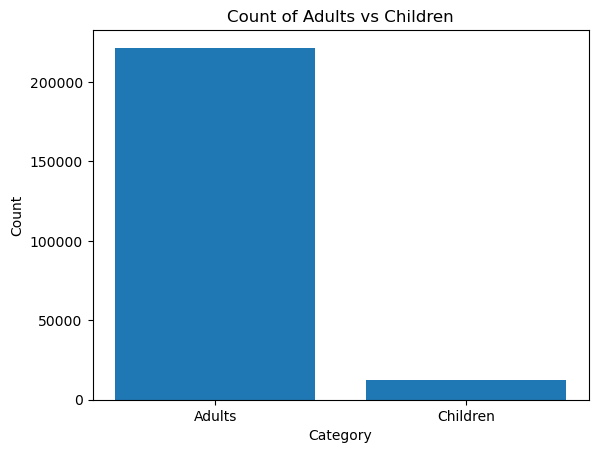

In [18]:
labels = ['Adults', 'Children']
values = [adult_count, children_count]

plt.bar(labels, values)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Count of Adults vs Children')

plt.show()

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119386 entries, 0 to 119385
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119386 non-null  object 
 1   is_canceled                     119386 non-null  int64  
 2   lead_time                       119386 non-null  int64  
 3   arrival_date_year               119386 non-null  int64  
 4   arrival_date_month              119386 non-null  object 
 5   arrival_date_week_number        119386 non-null  int64  
 6   arrival_date_day_of_month       119386 non-null  int64  
 7   stays_in_weekend_nights         119386 non-null  int64  
 8   stays_in_week_nights            119386 non-null  int64  
 9   adults                          119386 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119386 non-null  int64  
 12  meal            

# 7) Perform Label encoding on categorical columns

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
lencod = LabelEncoder()

In [25]:
data["hotel"] = lencod.fit_transform(data["hotel"])

In [26]:
data["arrival_date_month"] = lencod.fit_transform(data["arrival_date_month"])

In [27]:
data["meal"] = lencod.fit_transform(data["meal"])

In [28]:
data["country"] = lencod.fit_transform(data["country"])

In [29]:
data["market_segment"] = lencod.fit_transform(data["market_segment"])

In [30]:
data["distribution_channel"] = lencod.fit_transform(data["distribution_channel"])

In [31]:
data["reserved_room_type"] = lencod.fit_transform(data["reserved_room_type"])

In [32]:
data["assigned_room_type"] = lencod.fit_transform(data["assigned_room_type"])

In [33]:
data["deposit_type"] = lencod.fit_transform(data["deposit_type"])

In [34]:
data["customer_type"] = lencod.fit_transform(data["customer_type"])

In [35]:
data["reservation_status"] = lencod.fit_transform(data["reservation_status"])

In [36]:
data["reservation_status_date"] = lencod.fit_transform(data["reservation_status_date"])

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119386 entries, 0 to 119385
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119386 non-null  int64  
 1   is_canceled                     119386 non-null  int64  
 2   lead_time                       119386 non-null  int64  
 3   arrival_date_year               119386 non-null  int64  
 4   arrival_date_month              119386 non-null  int64  
 5   arrival_date_week_number        119386 non-null  int64  
 6   arrival_date_day_of_month       119386 non-null  int64  
 7   stays_in_weekend_nights         119386 non-null  int64  
 8   stays_in_week_nights            119386 non-null  int64  
 9   adults                          119386 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119386 non-null  int64  
 12  meal            

In [38]:
data.apply(pd.Series.unique)

hotel                                                                        [1, 0]
is_canceled                                                                  [0, 1]
lead_time                         [342, 737, 7, 13, 14, 0, 9, 85, 75, 23, 35, 68...
arrival_date_year                                                [2015, 2016, 2017]
arrival_date_month                           [5, 1, 11, 10, 9, 2, 4, 3, 7, 0, 8, 6]
arrival_date_week_number          [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 3...
arrival_date_day_of_month         [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
stays_in_weekend_nights           [0, 1, 2, 4, 3, 6, 13, 8, 5, 7, 12, 9, 16, 18,...
stays_in_week_nights              [0, 1, 2, 3, 4, 5, 10, 11, 8, 6, 7, 15, 9, 12,...
adults                            [2, 1, 3, 4, 40, 26, 50, 27, 55, 0, 20, 6, 5, 10]
children                                                 [0.0, 1.0, 2.0, 10.0, 3.0]
babies                                                             [0, 1, 2,

# Part 2: Model Building
# 1. Create features and target data

In [ ]:
x = data.drop("is_canceled", axis=1)
y = data["is_canceled"]

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.7, random_state=42)

# 3. Apply Random forest classifier on data

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
model = RandomForestClassifier()

In [45]:
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
model.score(x_train, y_train)*100

100.0

In [48]:
model.score(x_test, y_test)*100

100.0

In [51]:
ypred = model.predict(x_test)

# 4. Create function which show Precision score, recall score, accuracy, classification report and confusion matrix

In [52]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report, confusion_matrix

In [53]:
precision_score(y_test, ypred)

1.0

In [54]:
recall_score(y_test, ypred)

1.0

In [55]:
accuracy_score(y_test, ypred)

1.0

In [56]:
hit = confusion_matrix(y_test, ypred)
hit

array([[22488,     0],
       [    0, 13328]])

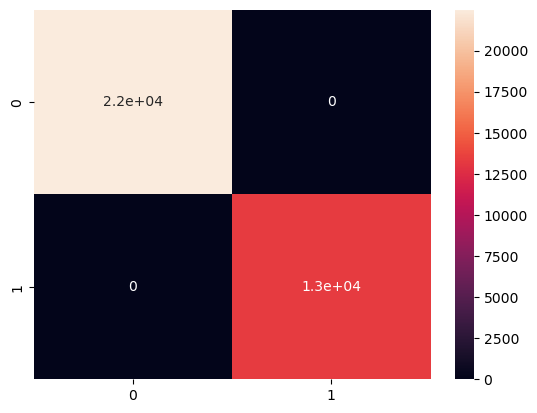

In [58]:
sns.heatmap(hit, annot=True);

In [60]:
print(classification_report(y_test, ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22488
           1       1.00      1.00      1.00     13328

    accuracy                           1.00     35816
   macro avg       1.00      1.00      1.00     35816
weighted avg       1.00      1.00      1.00     35816

